# Model Cleansing Pipeline for Conceptual Models

#### Modelset Dataset Generation

In [1]:
from mcp4cm.base import Dataset
from mcp4cm.uml.data_extraction import (
    filter_models_by_name_length,
    filter_models_by_name_count,
    filter_models_by_name_length_or_stopwords,
    filter_dummy_names,
    filter_dummy_classes,
    filter_classes_by_generic_pattern,
    filter_models_by_sequential_and_dummy_words
)
from mcp4cm.dataloading import load_dataset
from mcp4cm.base import DatasetType
import os


def get_models_dataset():
    uml_dataset = load_dataset(DatasetType.MODELSET, os.path.join('data', 'modelset'))

    Dataset.apply_filters(
        dataset=uml_dataset,
        filters=[
            filter_models_by_name_length_or_stopwords,
            filter_dummy_classes,
            filter_classes_by_generic_pattern,
            filter_dummy_names,
            filter_models_by_sequential_and_dummy_words,
            filter_models_by_name_length,
            filter_models_by_name_count,
        ],
    )
    return uml_dataset

uml_dataset = get_models_dataset()
len(uml_dataset)

Loading UML models:   0%|          | 0/5120 [00:00<?, ?it/s]

Flagged models with > 30.0% short names: 194
Flagged models with >= 25.0% short names and >= 40.0% of stopwords: 10
Models After Filtering: 4926. Filtered: 194


Filtering dummy classes:   0%|          | 0/4926 [00:00<?, ?it/s]

Flagged models based on dummy class percentage (Threshold: 50.0%)
Files fully dummy: 236
Files mostly valid (with few dummy classes): 15
Files with a mix of dummy and non-dummy classes: 13
Models After Filtering: 4675. Filtered: 251


Filtering generic classes:   0%|          | 0/4675 [00:00<?, ?it/s]

...

Filtering sequential and dummy words:   0%|          | 0/4636 [00:00<?, ?it/s]

Flagged models based on sequential patterns (Threshold: 75.0%)
Flagged models based on dummy word percentage (Threshold: 82.0%)
Flagged models based on vocabulary uniqueness (Threshold: 3)
Models After Filtering: 4546. Filtered: 90


Filtering models by name length:   0%|          | 0/4546 [00:00<?, ?it/s]

Filtered out 0 models with short names.
Models After Filtering with name counts between 5: 0


4546

### Dataset Loading

In [2]:
uml_dataset = load_dataset(DatasetType.MODELSET, os.path.join('data', 'modelset'))
archimate_dataset = load_dataset(DatasetType.EAMODELSET, os.path.join('data', 'eamodelset'))

Loading UML models:   0%|          | 0/5120 [00:00<?, ?it/s]

Loading Archimate Dataset @ data\eamodelset:   0%|          | 0/979 [00:00<?, ?it/s]

In [3]:
from mcp4cm.uml.data_extraction import extract_names_from_model
from tqdm.auto import tqdm

for model in tqdm(uml_dataset, desc="Extracting names from UML models"):
    extract_names_from_model(model)
    extract_names_from_model(model, use_types=True)

Extracting names from UML models:   0%|          | 0/5120 [00:00<?, ?it/s]

In [4]:
filter_models_by_name_length_or_stopwords(uml_dataset)

Flagged models with > 30.0% short names: 194
Flagged models with >= 25.0% short names and >= 40.0% of stopwords: 10
Models After Filtering: 4926. Filtered: 194


Dataset(name=modelset, models=4926)

In [5]:
filter_classes_by_generic_pattern(uml_dataset)

Filtering generic classes:   0%|          | 0/5120 [00:00<?, ?it/s]

Files containing more than one 'class: my class' or 'class: my class' followed by a number:
Models After Filtering based on generic class names (Threshold: 2)
Models After Filtering: 5083. Filtered: 37


Dataset(name=modelset, models=5083)

In [6]:
filter_models_by_name_length(uml_dataset)

Filtering models by name length:   0%|          | 0/5120 [00:00<?, ?it/s]

Filtered out 170 models with short names.


Dataset(name=modelset, models=4950)

In [7]:
filter_dummy_classes(uml_dataset)

Filtering dummy classes:   0%|          | 0/5120 [00:00<?, ?it/s]

Flagged models based on dummy class percentage (Threshold: 50.0%)
Files fully dummy: 236
Files mostly valid (with few dummy classes): 16
Files with a mix of dummy and non-dummy classes: 13
Models After Filtering: 4868. Filtered: 252


Dataset(name=modelset, models=4868)

In [8]:
filter_dummy_names(uml_dataset)

Filtering dummy names:   0%|          | 0/5120 [00:00<?, ?it/s]

Flagged 176 models based on dummy name percentage (Threshold: 30.0%)
Showing Top 10


Dataset(name=modelset, models=4944)

In [9]:
filter_models_by_sequential_and_dummy_words(uml_dataset)

Filtering sequential and dummy words:   0%|          | 0/5120 [00:00<?, ?it/s]

Flagged models based on sequential patterns (Threshold: 75.0%)
Flagged models based on dummy word percentage (Threshold: 82.0%)
Flagged models based on vocabulary uniqueness (Threshold: 3)
Models After Filtering: 5009. Filtered: 111


Dataset(name=modelset, models=5009)

In [10]:
Dataset.apply_filters(
    dataset=uml_dataset,
    filters=[
        filter_models_by_name_length_or_stopwords,
        filter_dummy_classes,
        filter_classes_by_generic_pattern,
        filter_dummy_names,
        filter_models_by_sequential_and_dummy_words,
        filter_models_by_name_length,
        filter_models_by_name_count,
    ],
)

Flagged models with > 30.0% short names: 194
Flagged models with >= 25.0% short names and >= 40.0% of stopwords: 10
Models After Filtering: 4926. Filtered: 194


Filtering dummy classes:   0%|          | 0/4926 [00:00<?, ?it/s]

Flagged models based on dummy class percentage (Threshold: 50.0%)
Files fully dummy: 236
Files mostly valid (with few dummy classes): 15
Files with a mix of dummy and non-dummy classes: 13
Models After Filtering: 4675. Filtered: 251


Filtering generic classes:   0%|          | 0/4675 [00:00<?, ?it/s]

Files containing more than one 'class: my class' or 'class: my class' followed by a number:
Models After Filtering based on generic class names (Threshold: 2)
Models After Filtering: 4640. Filtered: 35


...

Filtering sequential and dummy words:   0%|          | 0/4636 [00:00<?, ?it/s]

Flagged models based on sequential patterns (Threshold: 75.0%)
Flagged models based on dummy word percentage (Threshold: 82.0%)
Flagged models based on vocabulary uniqueness (Threshold: 3)
Models After Filtering: 4546. Filtered: 90


Filtering models by name length:   0%|          | 0/4546 [00:00<?, ?it/s]

Filtered out 0 models with short names.
Models After Filtering with name counts between 5: 0


Dataset(name=modelset, models=4546)

### Filtering by Language

In [11]:
from mcp4cm.language_detection import filter_models_by_language


uml_english_models = filter_models_by_language(uml_dataset, 'english')
archimate_english_models = filter_models_by_language(archimate_dataset, 'en')
uml_english_models, archimate_english_models

(Dataset(name=modelset, models=3932), Dataset(name=Archimate, models=580))

### Plotting Results

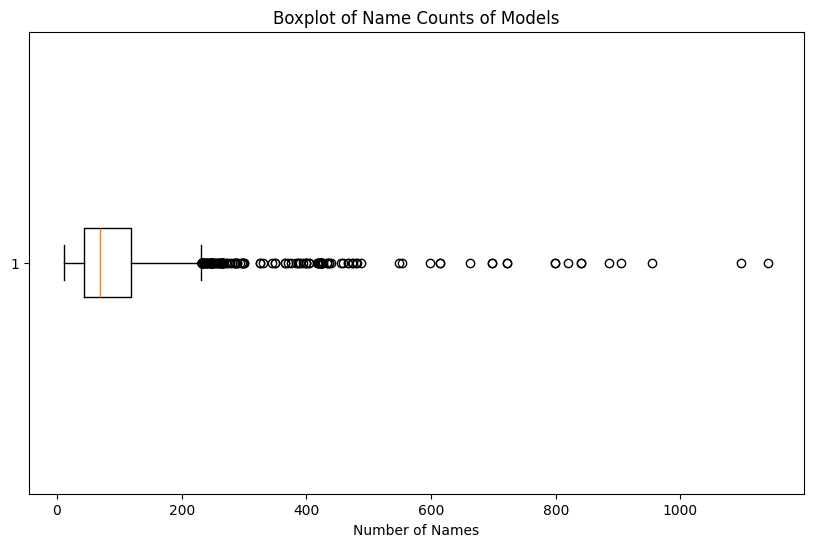

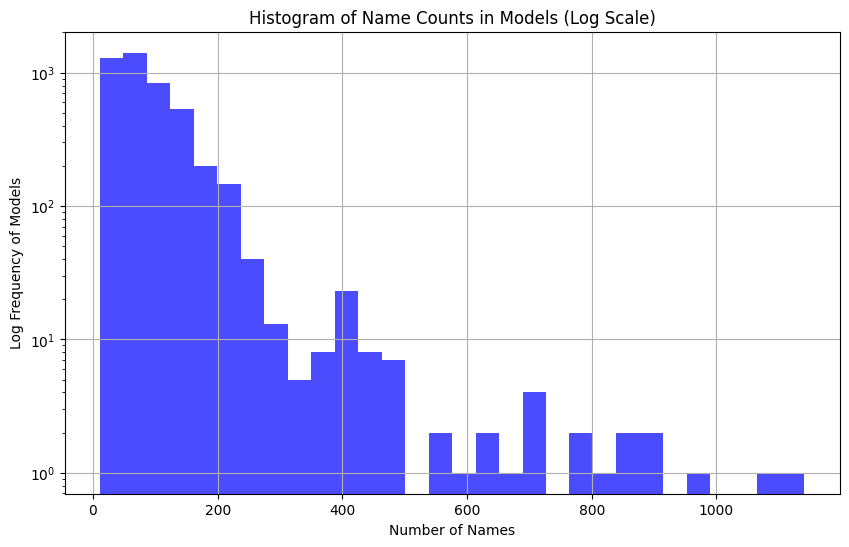

{'0c5d701a-fd92-4732-975e-56919857c0d7.xmi': 1141,
 '_iqBtwK3gEemHYc7DDM2g2A.xmi': 1097,
 '_ypy5gIoQEeq3N_Xh6gsEIQ.xmi': 954,
 '_l4uH4BkLEeqDmNBP3mfLQg.xmi': 905,
 '_uj5zoENuEeqonN_RS9oRzw.xmi': 885,
 '_5IGhMBAyEeimSO_GhE8jew.xmi': 840,
 '49aa0d6e-dd03-4380-824f-f8aed9689fd8.xmi': 840,
 'c7635f0a-1a15-40fa-9a9b-60117bc1924f.xmi': 819,
 '73872d16-4cfd-451c-8924-84aba4d32a6c.xmi': 798,
 '3fe05ac1-4dc0-4298-bd8a-765783d90525.xmi': 798,
 '84dc40c4-1c02-441e-a08c-cc3e98134c58.xmi': 722,
 '_GhrU0JEJEemqpd237shV0A.xmi': 721,
 '8a70f32a-16c6-45b2-8ced-9ca375092adf.xmi': 697,
 '621bbbc5-f81d-437f-b493-e9355c7a71eb.xmi': 697,
 '_yMPRkHTAEemwWpuaZV3QLQ.xmi': 662,
 '7fc9b898-2499-4c6d-9c0f-b4cd417df6c1.xmi': 614,
 'e761a736-ea61-4d94-a0cb-48097a85aa94.xmi': 614,
 '57db9265-afee-41c2-92cb-44b23b9a5c39.xmi': 598,
 '_UD2f0FPqEeqK2M3E1LfZ7Q.xmi': 553,
 '_vGuQQGnjEeqghpCovSsunw.xmi': 548,
 '_DyDa8IwpEemq7_yOQcm9ow.xmi': 488,
 '_d3g8QHozEemKc6sUMthxaw.xmi': 482,
 '_cPF4MFimEeqK2M3E1LfZ7Q.xmi': 479,
 '_j

In [12]:
from mcp4cm.uml.data_extraction import extract_names_counts_from_dataset


extract_names_counts_from_dataset(uml_dataset, plt_figs=True)

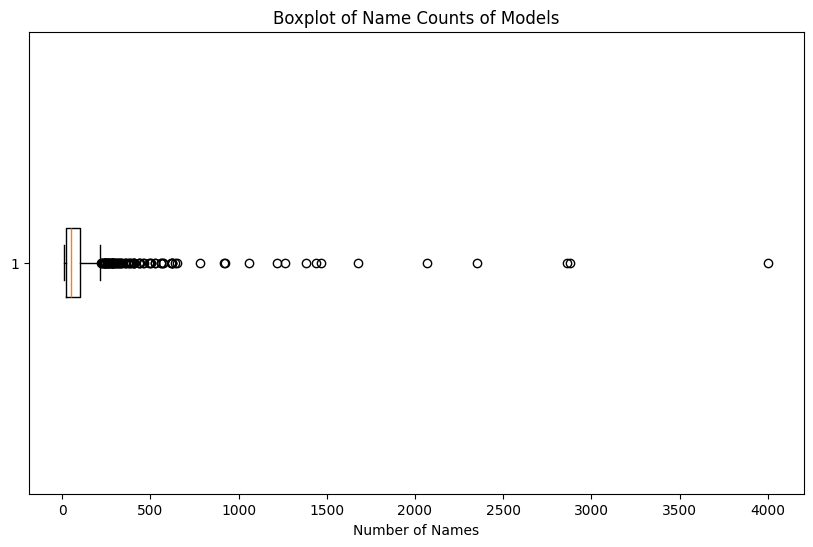

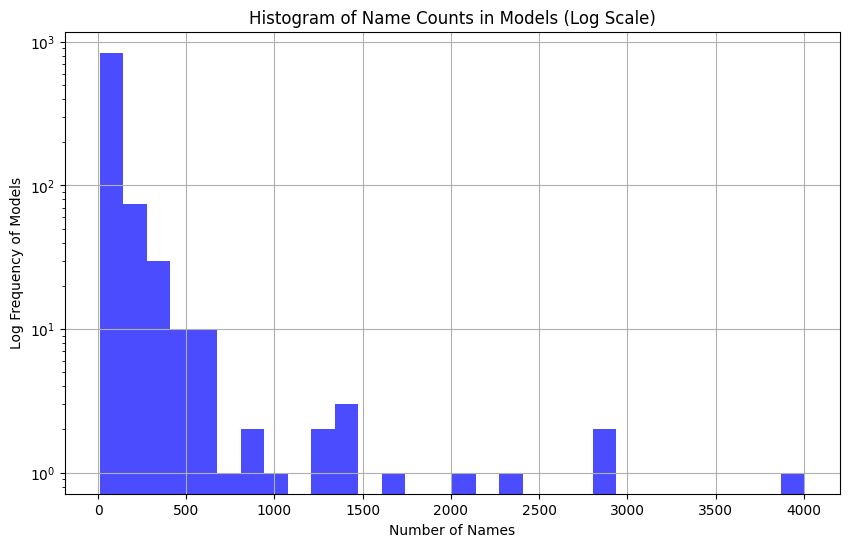

Total models: 978
Total names: 89104


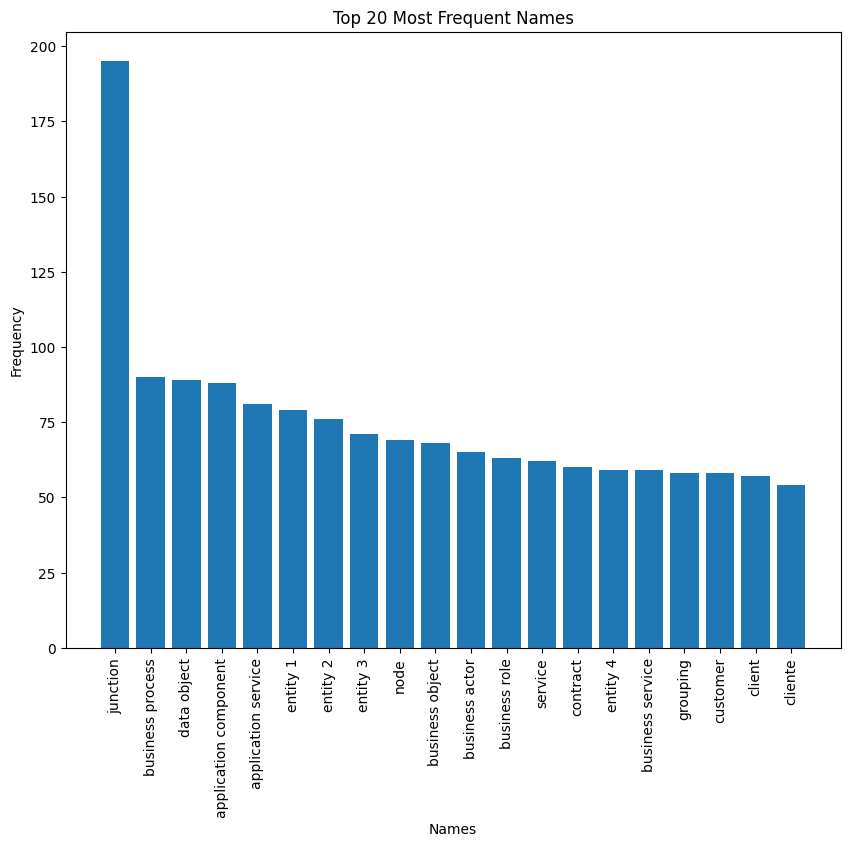

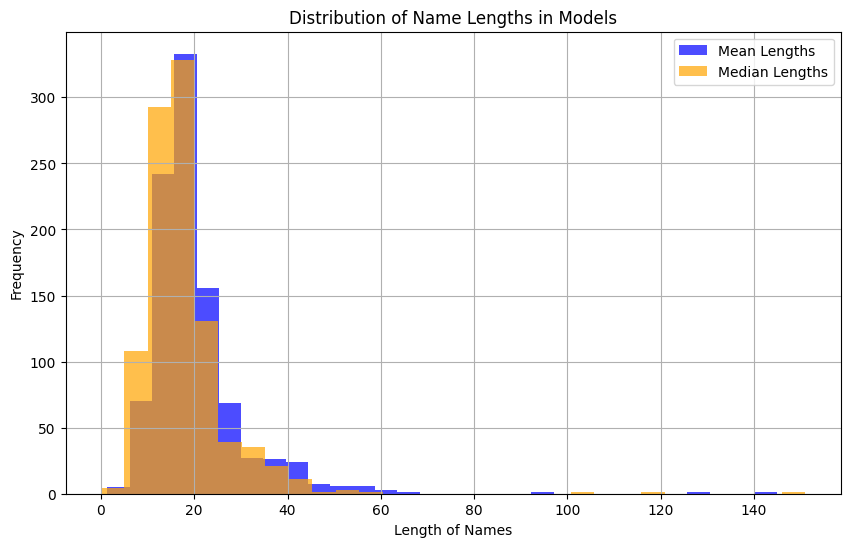

Flagged models with > 50.0% short names: 1
Filtered models: 977


Filtering dummy names:   0%|          | 0/978 [00:00<?, ?it/s]

Flagged 0 models based on dummy name percentage (Threshold: 30.0%)
Showing Top 10


Dataset(name=Archimate, models=978)

In [13]:
from mcp4cm.archimate.data_extraction import (
    extract_names_counts_from_dataset,
    get_word_counts_from_dataset,
    get_name_length_distribution,
    filter_models_by_name_length_or_stopwords,
    filter_dummy_names
)

extract_names_counts_from_dataset(archimate_dataset, plt_figs=True)
get_word_counts_from_dataset(archimate_dataset, plt_fig=True, topk=20)
get_name_length_distribution(archimate_dataset, plt_fig=True)
filter_models_by_name_length_or_stopwords(archimate_dataset)
filter_dummy_names(archimate_dataset)

### Dataset Deduplication

Hashing and duplicate detection took 0.02 seconds.
Total files processed: 4546
Total unique files: 2344
Total duplicate files: 2202
Duplicate groups: 359


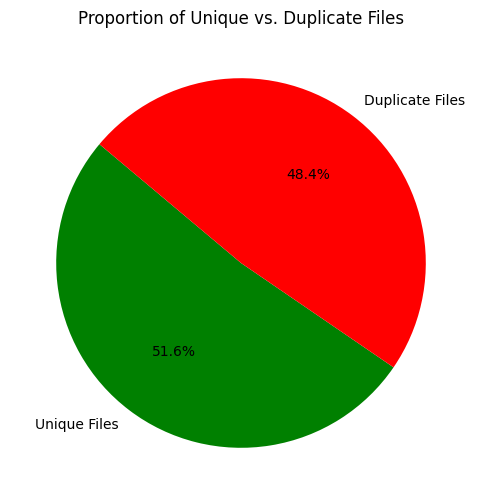

In [14]:
import hashlib
import time
import matplotlib.pyplot as plt
from mcp4cm.base import Dataset


def get_file_hash(string: str) -> str:
    """
    Compute a SHA-256 hash for the content of a file.
    
    Args:
        string (str): The content of the file to hash.
    
    Returns:
        str: The SHA-256 hash of the file content.
    
    Example:
        >>> hash_value = get_file_hash("example content")
        >>> print(hash_value)
        '5d41402abc4b2a76b9719d911017c592'
    """    
    
    return hashlib.sha256(string.encode()).hexdigest()  # Hash the content
    


def detect_duplicates_by_hash(
    dataset: Dataset, 
    hash_function=get_file_hash, 
    key: str='names', 
    inplace: bool=False, 
    plt_fig: bool=False
):
    """
    Detect duplicate UML models based on their hash values.
    
    This function identifies exact duplicates in a dataset by computing hash values
    for each model's content. It can optionally modify the dataset in-place to remove
    duplicates and visualize the duplicate distribution.
    
    Args:
        dataset (UMLDataset): The dataset containing UML models.
        hash_function (callable): Function to compute hash values. Defaults to get_file_hash.
        inplace (bool): If True, removes duplicates from the dataset. Defaults to False.
        plt_fig (bool): If True, displays a pie chart of unique vs. duplicate files. Defaults to False.
    
    Returns:
        tuple: A tuple containing:
            - List[UMLModel]: A list of unique UML models.
            - List[tuple]: A list of duplicate groups, where each group is a tuple of (original, duplicate).
    
    Example:
        >>> unique_models, duplicate_groups = detect_duplicates_by_hash(dataset, inplace=True)
        >>> print(f"Found {len(duplicate_groups)} duplicate groups")
    """
    
    hash_dict = {}
    unique_files = []
    duplicate_files = []
    
    assert all(hasattr(model, key) for model in dataset.models), f"All models must have a '{key}' attribute"
    
    start_time = time.time()
    for model in dataset.models:
        content = "\n".join(model.names_with_types if hasattr(model, 'names_with_types') else model.names)
        file_hash = hash_function(content)
        if file_hash is not None:
            if file_hash not in hash_dict:
                hash_dict[file_hash] = list()
                
            hash_dict[file_hash].append(content)
            # print(model.file_path, file_hash)  # Print the file path and its hash for debugging
    
    duplicate_files = {h: files for h, files in hash_dict.items() if len(files) > 1}
    unique_files = {h: files[0] for h, files in hash_dict.items() if len(files) == 1}
    
    
    
    end_time = time.time()
    print(f"Hashing and duplicate detection took {end_time - start_time:.2f} seconds.")
    print(f"Total files processed: {len(dataset)}")
    print(f"Total unique files: {len(unique_files)}")
    print(f"Total duplicate files: {len(dataset) - len(unique_files)}")
    print(f"Duplicate groups: {len(duplicate_files)}")
    
    if inplace:
        dataset.models = unique_files
    
    if plt_fig:
        labels = ['Unique Files', 'Duplicate Files']
        sizes = [len(unique_files), len(dataset) - len(unique_files)]
        colors = ['green', 'red']

        plt.figure(figsize=(6, 6))
        plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=140)
        plt.title("Proportion of Unique vs. Duplicate Files")
        plt.show()
    
    # return unique_files, duplicate_groups


detect_duplicates_by_hash(
    uml_dataset,
    key='names_with_types',
    plt_fig=True
)

2703
TF-IDF and duplicate detection took 0.73 seconds.

=== Dataset Statistics ===
Total files processed: 2947
Total unique files: 1207
Total duplicate files: 1740
Number of duplicate groups: 110


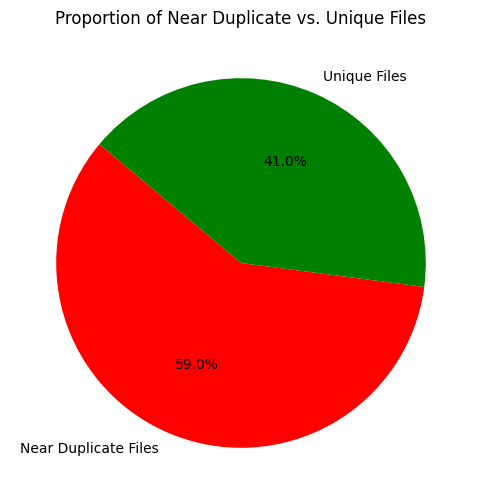

In [15]:
from collections import defaultdict
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity



def tfidf_near_duplicate_detector(
    dataset: Dataset, 
    key='names', 
    threshold: float=0.8, 
    inplace: bool=False, 
    plt_fig: bool=False
):
    """
    Detect near-duplicate UML models based on TF-IDF vectorization and cosine similarity.
    
    This function identifies near-duplicate models by computing TF-IDF vectors
    for model text content and measuring their cosine similarity. Models with
    similarity above the threshold are considered near-duplicates.
    
    Args:
        dataset (UMLDataset): The dataset containing UML models.
        threshold (float): The similarity threshold for considering two models as near-duplicates.
            Values range from 0 to 1, with 1 being identical. Defaults to TFIDF_DUPLICATE_THRESHOLD.
        inplace (bool): If True, removes near-duplicates from the dataset. Defaults to False.
        plt_fig (bool): If True, displays a pie chart of unique vs. near-duplicate files. Defaults to False.
    
    Returns:
        tuple: A tuple containing:
            - List[UMLModel]: A list of unique UML models.
            - List[tuple]: A list of near-duplicate groups, where each group is a tuple of (model1, model2).
    
    Example:
        >>> unique_models, near_duplicate_groups = tfidf_near_duplicate_detector(dataset, threshold=0.85)
        >>> print(f"Found {len(near_duplicate_groups)} near-duplicate groups with threshold {threshold}")
    """
    
    def get_content(m):
        if key in ['names', 'names_with_types']:
            content = "\n".join(m.names_with_types if hasattr(m, 'names_with_types') else m.names)
        else:
            content = m.get_text(key)
        return content
    
    # Extract the text content from the models
    hash_dict = dict()
    for model in dataset.models:
        file_hash = get_file_hash(get_content(model))
        if file_hash is not None:
            if file_hash not in hash_dict:
                hash_dict[file_hash] = list()
            hash_dict[file_hash].append(model)
            # print(model.file_path, file_hash)  # Print the file path and its hash for debugging
    
    duplicate_files = {h: models for h, models in hash_dict.items() if len(models) > 1}
    unique_files = {h: models[0] for h, models in hash_dict.items() if len(models) == 1}
    
    files_content = list()
    filenames = list()
    for models in duplicate_files.values():
        files_content.append(get_content(models[0]))
        filenames.append(model.file_path)
    
    for model in unique_files.values():
        files_content.append(get_content(model))
        filenames.append(model.file_path)
    
    print(len(files_content))
    
    start_time = time.time()

    # Compute TF-IDF vectors
    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform(files_content)

    # Compute cosine similarity matrix
    similarity_matrix = cosine_similarity(tfidf_matrix)

    # Set a similarity threshold
    similarity_threshold = threshold

    # Initialize groups of duplicates
    duplicate_groups = defaultdict(list)
    unique_files_indices = set(range(len(filenames)))  # Track indices of potentially unique files

    # Efficient file comparison
    for i in range(len(filenames)):
        found_group = False
        file1 = os.path.basename(filenames[i])

        for group_id, members in list(duplicate_groups.items()):
            for member_index in members:
                if member_index != i and similarity_matrix[i][member_index] > similarity_threshold:
                    duplicate_groups[group_id].append(i)
                    found_group = True
                    unique_files_indices.discard(i)  # Remove from unique files if found duplicate
                    break
            if found_group:
                break

        # If no existing group is similar, start a new group
        if not found_group and i in unique_files_indices:
            duplicate_groups[file1].append(i)

    print(f"TF-IDF and duplicate detection took {time.time() - start_time:.2f} seconds.")
    
    near_duplicate_count = sum(len(indices) for indices in duplicate_groups.values() if len(indices) > 1)
    number_of_duplicate_groups = sum(1 for indices in duplicate_groups.values() if len(indices) > 1)
    unique_file_count = len(unique_files_indices) - number_of_duplicate_groups
    total_files_processed = near_duplicate_count + unique_file_count

    
    if inplace:
        unique_files = [model for model in dataset.models if model not in [dup[1] for dup in duplicate_groups]]
        dataset.models = unique_files
    
    print("\n=== Dataset Statistics ===")
    print(f"Total files processed: {total_files_processed}")
    print(f"Total unique files: {unique_file_count}")
    print(f"Total duplicate files: {near_duplicate_count}")
    print(f"Number of duplicate groups: {number_of_duplicate_groups}")

    # Labels and sizes for the pie chart
    labels = ['Near Duplicate Files', 'Unique Files']
    sizes = [near_duplicate_count, unique_file_count]
    colors = ['red', 'green']
    if plt_fig:
        # Create the pie chart
        plt.figure(figsize=(6, 6))
        plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=140)
        plt.title("Proportion of Near Duplicate vs. Unique Files")
        plt.show()


tfidf_near_duplicate_detector(
    uml_dataset,
    key='names_with_types',
    plt_fig=True
)

935
TF-IDF and duplicate detection took 0.29 seconds.

=== Dataset Statistics ===
Total files processed: 1746
Total unique files: 811
Total duplicate files: 935
Number of duplicate groups: 1


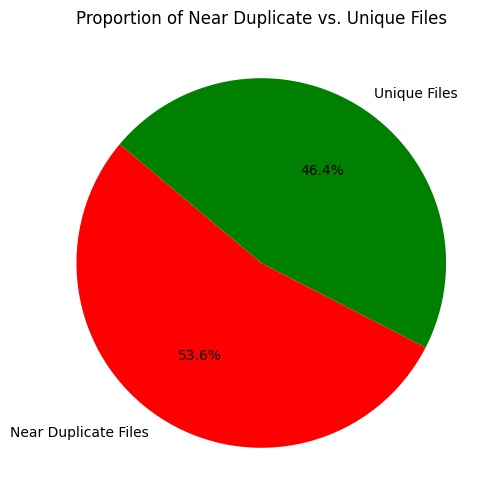

In [16]:
tfidf_near_duplicate_detector(
    archimate_dataset,
    key='names',
    plt_fig=True
)

935
TF-IDF and duplicate detection took 0.32 seconds.

=== Dataset Statistics ===
Total files processed: 1720
Total unique files: 785
Total duplicate files: 935
Number of duplicate groups: 1


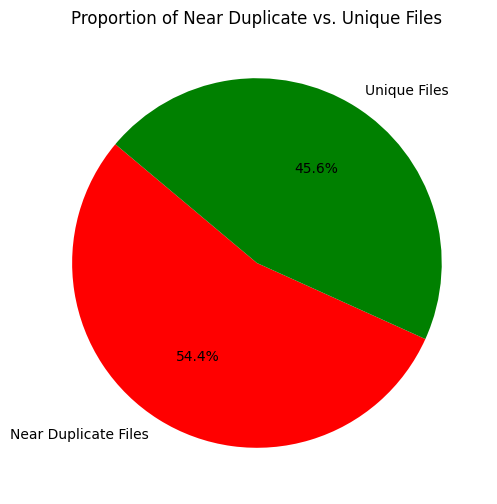

In [17]:
tfidf_near_duplicate_detector(
    archimate_dataset,
    key='names_with_layers_and_types',
    plt_fig=True
)